# Linear RUL (Assumes engine degradation immediately after start)

In [16]:
def minmax_normalize_except_rul(train_df, test_df=None, target_col="RUL", exclude_cols=None):
    """
    Min-max normalize numeric columns except target_col.
    If test_df is provided, use train min/max to transform test_df.
    """
    train_out = train_df.copy()
    test_out = test_df.copy() if test_df is not None else None

    exclude = set(exclude_cols or [])
    exclude.add(target_col)

    cols_to_scale = [
        c for c in train_out.columns
        if c not in exclude and pd.api.types.is_numeric_dtype(train_out[c])
    ]

    # Force scaled columns to float first to avoid dtype assignment error
    train_out[cols_to_scale] = train_out[cols_to_scale].astype("float64")
    if test_out is not None:
        test_out[cols_to_scale] = test_out[cols_to_scale].astype("float64")

    mins = train_df[cols_to_scale].min()
    maxs = train_df[cols_to_scale].max()
    ranges = maxs - mins

    non_constant_cols = ranges[ranges != 0].index.tolist()
    constant_cols = ranges[ranges == 0].index.tolist()

    # Set all to 0 first (constant columns remain 0)
    train_out[cols_to_scale] = 0.0
    if test_out is not None:
        test_out[cols_to_scale] = 0.0

    # Scale only non-constant columns
    if non_constant_cols:
        train_out[non_constant_cols] = (
            (train_df[non_constant_cols] - mins[non_constant_cols]) / ranges[non_constant_cols]
        )
        if test_out is not None:
            test_out[non_constant_cols] = (
                (test_df[non_constant_cols] - mins[non_constant_cols]) / ranges[non_constant_cols]
            )

    stats = {
        "scaled_columns": cols_to_scale,
        "constant_columns_set_to_0": constant_cols,
        "train_min": mins,
        "train_max": maxs,
    }

    return train_out, test_out, stats

In [ ]:
# Initial preprocessing pipeline with numeric RUL labels only, then export to CSV
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# -----------------------------
# 1) Load raw competition data
# -----------------------------
train_raw = pd.read_csv('../data/nasa-data/train_FD001.txt', sep=r'\s+', header=None)
test_raw = pd.read_csv('../data/nasa-data/test_FD001.txt', sep=r'\s+', header=None)

# Keep only valid columns (drop trailing whitespace columns if present)
train_raw = train_raw.iloc[:, :26].copy()
test_raw = test_raw.iloc[:, :26].copy()

base_cols = [
    'id', 'cycle', 'setting1', 'setting2', 'setting3',
    's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10',
    's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21'
 ]
train_raw.columns = base_cols
test_raw.columns = base_cols

# ----------------------------------
# 2) Create numeric RUL labels only
# ----------------------------------
# Train RUL: max cycle per engine - current cycle
train_max_cycle = train_raw.groupby('id', as_index=False)['cycle'].max().rename(columns={'cycle': 'max_cycle'})
train_proc = train_raw.merge(train_max_cycle, on='id', how='left')
train_proc['RUL'] = train_proc['max_cycle'] - train_proc['cycle']
train_proc = train_proc.drop(columns=['max_cycle'])

# Test RUL: use NASA ground truth file for remaining life after last observed cycle
truth_df = pd.read_csv('../data/nasa-data/RUL_FD001.txt', sep=r'\s+', header=None).iloc[:, :1].copy()
truth_df.columns = ['more']
truth_df['id'] = np.arange(1, len(truth_df) + 1)

test_last_cycle = test_raw.groupby('id', as_index=False)['cycle'].max().rename(columns={'cycle': 'last_cycle'})
truth_df = truth_df.merge(test_last_cycle, on='id', how='left')
truth_df['max_cycle'] = truth_df['last_cycle'] + truth_df['more']
truth_df = truth_df[['id', 'max_cycle']]

test_proc = test_raw.merge(truth_df, on='id', how='left')
test_proc['RUL'] = test_proc['max_cycle'] - test_proc['cycle']
test_proc = test_proc.drop(columns=['max_cycle'])

# Reorder columns so RUL is the last column
ordered_cols = [c for c in train_proc.columns if c != 'RUL'] + ['RUL']
train_processed_rul = train_proc[ordered_cols]
test_processed_rul = test_proc[ordered_cols]
train_norm_df, test_norm_df, norm_stats = minmax_normalize_except_rul(
    train_processed_rul, test_processed_rul, target_col="RUL"
)

# ----------------
# 4) Export to CSV
# ----------------
out_dir = Path('../data/processed-nasa-data/data_cleaning_1/linear_rul_1')
out_dir.mkdir(parents=True, exist_ok=True)

train_out_path = out_dir / 'train_processed_rul_only_fd001.csv'
test_out_path = out_dir / 'test_processed_rul_only_fd001.csv'

train_norm_df.to_csv(train_out_path, index=False)
test_norm_df.to_csv(test_out_path, index=False)

# Also export equivalent without minmax norm just for ref
out_dir = Path('../data/processed-nasa-data/data_cleaning_1/linear_rul_no_norm_0')
out_dir.mkdir(parents=True, exist_ok=True)

train_out_path = out_dir / 'train_processed_rul_only_fd001.csv'
test_out_path = out_dir / 'test_processed_rul_only_fd001.csv'

train_processed_rul.to_csv(train_out_path, index=False)
test_processed_rul.to_csv(test_out_path, index=False)

print(f'Saved: {train_out_path}  shape={train_norm_df.shape}')
print(f'Saved: {test_out_path}  shape={test_norm_df.shape}')
print('Label format: numeric RUL only (no binary label columns).')

Saved: ..\data\processed-nasa-data\data_cleaning_1\linear_no_norm_0\train_processed_rul_only_fd001.csv  shape=(20631, 27)
Saved: ..\data\processed-nasa-data\data_cleaning_1\linear_no_norm_0\test_processed_rul_only_fd001.csv  shape=(13096, 27)
Label format: numeric RUL only (no binary label columns).


In [ ]:
# Initial preprocessing pipeline with numeric RUL labels only, then export to CSV
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# -----------------------------
# 1) Load raw competition data
# -----------------------------
train_raw = pd.read_csv('../data/nasa-data/train_FD002.txt', sep=r'\s+', header=None)
test_raw = pd.read_csv('../data/nasa-data/test_FD002.txt', sep=r'\s+', header=None)

# Keep only valid columns (drop trailing whitespace columns if present)
train_raw = train_raw.iloc[:, :26].copy()
test_raw = test_raw.iloc[:, :26].copy()

base_cols = [
    'id', 'cycle', 'setting1', 'setting2', 'setting3',
    's1', 's2', 's3', 's4', 's5', 's6', 's7', 's8', 's9', 's10',
    's11', 's12', 's13', 's14', 's15', 's16', 's17', 's18', 's19', 's20', 's21'
 ]
train_raw.columns = base_cols
test_raw.columns = base_cols

# ----------------------------------
# 2) Create numeric RUL labels only
# ----------------------------------
# Train RUL: max cycle per engine - current cycle
train_max_cycle = train_raw.groupby('id', as_index=False)['cycle'].max().rename(columns={'cycle': 'max_cycle'})
train_proc = train_raw.merge(train_max_cycle, on='id', how='left')
train_proc['RUL'] = train_proc['max_cycle'] - train_proc['cycle']
train_proc = train_proc.drop(columns=['max_cycle'])

# Test RUL: use NASA ground truth file for remaining life after last observed cycle
truth_df = pd.read_csv('../data/nasa-data/RUL_FD002.txt', sep=r'\s+', header=None).iloc[:, :1].copy()
truth_df.columns = ['more']
truth_df['id'] = np.arange(1, len(truth_df) + 1)

test_last_cycle = test_raw.groupby('id', as_index=False)['cycle'].max().rename(columns={'cycle': 'last_cycle'})
truth_df = truth_df.merge(test_last_cycle, on='id', how='left')
truth_df['max_cycle'] = truth_df['last_cycle'] + truth_df['more']
truth_df = truth_df[['id', 'max_cycle']]

test_proc = test_raw.merge(truth_df, on='id', how='left')
test_proc['RUL'] = test_proc['max_cycle'] - test_proc['cycle']
test_proc = test_proc.drop(columns=['max_cycle'])

# Reorder columns so RUL is the last column
ordered_cols = [c for c in train_proc.columns if c != 'RUL'] + ['RUL']
train_processed_rul = train_proc[ordered_cols]
test_processed_rul = test_proc[ordered_cols]
train_norm_df, test_norm_df, norm_stats = minmax_normalize_except_rul(
    train_processed_rul, test_processed_rul, target_col="RUL", exclude_cols=["id"]
)

# ----------------
# 4) Export to CSV
# ----------------
out_dir = Path('../data/processed-nasa-data/data_cleaning_1/linear_rul_1')
out_dir.mkdir(parents=True, exist_ok=True)

train_out_path = out_dir / 'train_processed_rul_only_fd002.csv'
test_out_path = out_dir / 'test_processed_rul_only_fd002.csv'

train_processed_rul.to_csv(train_out_path, index=False)
test_processed_rul.to_csv(test_out_path, index=False)

# Also export equivalent without minmax norm just for ref
out_dir = Path('../data/processed-nasa-data/data_cleaning_1/linear_rul_no_norm_0')
out_dir.mkdir(parents=True, exist_ok=True)

train_out_path = out_dir / 'train_processed_rul_only_fd002.csv'
test_out_path = out_dir / 'test_processed_rul_only_fd002.csv'

train_processed_rul.to_csv(train_out_path, index=False)
test_processed_rul.to_csv(test_out_path, index=False)

print(f'Saved: {train_out_path}  shape={train_norm_df.shape}')
print(f'Saved: {test_out_path}  shape={test_norm_df.shape}')
print('Label format: numeric RUL only (no binary label columns).')

Saved: ..\data\processed-nasa-data\data_cleaning_1\linear_no_norm_0\train_processed_rul_only_fd002.csv  shape=(53759, 27)
Saved: ..\data\processed-nasa-data\data_cleaning_1\linear_no_norm_0\test_processed_rul_only_fd002.csv  shape=(33991, 27)
Label format: numeric RUL only (no binary label columns).


# Piecewise RUL, only keeps where engines are well represented

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_cycle_distribution(fd001_df, fd002_df, cycle_col="cycle", bins=60):
    # Basic checks
    if cycle_col not in fd001_df.columns or cycle_col not in fd002_df.columns:
        raise ValueError(f"Both dataframes must contain '{cycle_col}'")

    s1 = fd001_df[cycle_col].dropna()
    s2 = fd002_df[cycle_col].dropna()

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

    # Side-by-side histograms
    axes[0].hist(s1, bins=bins, alpha=0.7, label="FD001", edgecolor="black")
    axes[0].hist(s2, bins=bins, alpha=0.5, label="FD002", edgecolor="black")
    axes[0].set_title("Cycle Distribution (Overlay)")
    axes[0].set_xlabel("Cycle")
    axes[0].set_ylabel("Row count")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Boxplot comparison
    axes[1].boxplot([s1.values, s2.values], labels=["FD001", "FD002"], vert=True)
    axes[1].set_title("Cycle Distribution (Boxplot)")
    axes[1].set_ylabel("Cycle")
    axes[1].grid(alpha=0.3)

    plt.show()

    # Summary table
    summary = pd.DataFrame({
        "FD001": s1.describe(),
        "FD002": s2.describe()
    })
    display(summary)
    return summary

C:\Users\tohhy\AppData\Local\Temp\ipykernel_600\4284237533.py:25: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([s1.values, s2.values], labels=["FD001", "FD002"], vert=True)


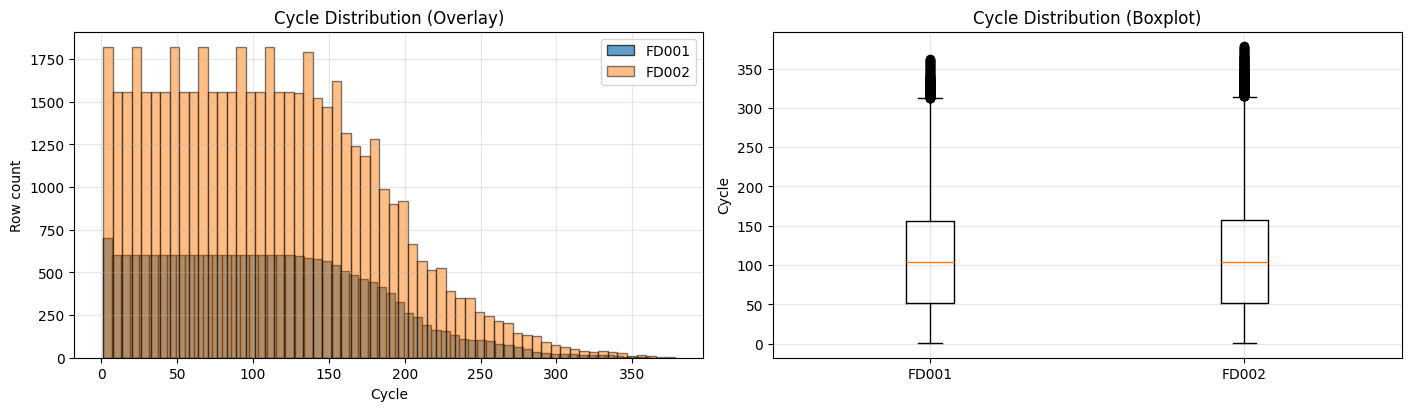

,FD001,FD002
count,20631.000000,53759.000000
mean,108.807862,109.154746
std,68.880990,69.180569
min,1.000000,1.000000
25%,52.000000,52.000000
50%,104.000000,104.000000
75%,156.000000,157.000000
max,362.000000,378.000000


,FD001,FD002
count,20631.000000,53759.000000
mean,108.807862,109.154746
std,68.880990,69.180569
min,1.000000,1.000000
25%,52.000000,52.000000
50%,104.000000,104.000000
75%,156.000000,157.000000
max,362.000000,378.000000


In [20]:
base_cols = [
    "id", "cycle", "setting1", "setting2", "setting3",
    "s1", "s2", "s3", "s4", "s5", "s6", "s7", "s8", "s9", "s10",
    "s11", "s12", "s13", "s14", "s15", "s16", "s17", "s18", "s19", "s20", "s21"
]

fd001_train = pd.read_csv("../data/nasa-data/train_FD001.txt", sep=r"\s+", header=None).iloc[:, :26]
fd002_train = pd.read_csv("../data/nasa-data/train_FD002.txt", sep=r"\s+", header=None).iloc[:, :26]
fd001_train.columns = base_cols
fd002_train.columns = base_cols

plot_cycle_distribution(fd001_train, fd002_train)

In [ ]:
# Since any RUL above ~150, we can see a dropoff in the number of engines
# We can cap the RUL at 150 and only update if it is less than 150
# It is basically the same as above for Linear but we just keep the RULs > 150 at 150 
from pathlib import Path
import pandas as pd
import numpy as np

def build_piecewise_rul(fd_tag, cap_value=150, out_dir="../data/processed-nasa-data/data_cleaning_1/piecewise_rul_2"):
    # 1) Load raw
    train_raw = pd.read_csv(f"../data/nasa-data/train_{fd_tag}.txt", sep=r"\s+", header=None).iloc[:, :26].copy()
    test_raw = pd.read_csv(f"../data/nasa-data/test_{fd_tag}.txt", sep=r"\s+", header=None).iloc[:, :26].copy()

    base_cols = [
        "id", "cycle", "setting1", "setting2", "setting3",
        "s1", "s2", "s3", "s4", "s5", "s6", "s7", "s8", "s9", "s10",
        "s11", "s12", "s13", "s14", "s15", "s16", "s17", "s18", "s19", "s20", "s21"
    ]
    train_raw.columns = base_cols
    test_raw.columns = base_cols

    # 2) Train linear RUL -> piecewise cap
    train_max_cycle = train_raw.groupby("id", as_index=False)["cycle"].max().rename(columns={"cycle": "max_cycle"})
    train_proc = train_raw.merge(train_max_cycle, on="id", how="left")
    train_proc["RUL"] = train_proc["max_cycle"] - train_proc["cycle"]
    train_proc["RUL"] = train_proc["RUL"].clip(upper=cap_value)
    train_proc = train_proc.drop(columns=["max_cycle"])

    # 3) Test linear RUL (using truth) -> piecewise cap
    truth_df = pd.read_csv(f"../data/nasa-data/RUL_{fd_tag}.txt", sep=r"\s+", header=None).iloc[:, :1].copy()
    truth_df.columns = ["more"]
    truth_df["id"] = np.arange(1, len(truth_df) + 1)

    test_last_cycle = test_raw.groupby("id", as_index=False)["cycle"].max().rename(columns={"cycle": "last_cycle"})
    truth_df = truth_df.merge(test_last_cycle, on="id", how="left")
    truth_df["max_cycle"] = truth_df["last_cycle"] + truth_df["more"]
    truth_df = truth_df[["id", "max_cycle"]]

    test_proc = test_raw.merge(truth_df, on="id", how="left")
    test_proc["RUL"] = test_proc["max_cycle"] - test_proc["cycle"]
    test_proc["RUL"] = test_proc["RUL"].clip(upper=cap_value)
    test_proc = test_proc.drop(columns=["max_cycle"])

    # 4) Reorder + save
    ordered_cols = [c for c in train_proc.columns if c != "RUL"] + ["RUL"]
    train_out_df = train_proc[ordered_cols]
    test_out_df = test_proc[ordered_cols]
    train_norm_df, test_norm_df, norm_stats = minmax_normalize_except_rul(
        train_out_df, test_out_df, target_col="RUL", exclude_cols=["id"]
    )

    save_dir = Path(out_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    train_out_path = save_dir / f"train_processed_rul_piecewise_{cap_value}_{fd_tag.lower()}.csv"
    test_out_path = save_dir / f"test_processed_rul_piecewise_{cap_value}_{fd_tag.lower()}.csv"

    train_norm_df.to_csv(train_out_path, index=False)
    test_norm_df.to_csv(test_out_path, index=False)

    print(f"{fd_tag} saved:")
    print(f"  train -> {train_out_path} shape={train_out_df.shape}")
    print(f"  test  -> {test_out_path} shape={test_out_df.shape}")
    print(f"  RUL max (train/test): {train_out_df['RUL'].max()} / {test_out_df['RUL'].max()}")
    print("-" * 70)

# Run for both datasets
build_piecewise_rul("FD001", cap_value=150) # From observation
build_piecewise_rul("FD002", cap_value=150) # From observation
build_piecewise_rul("FD001", cap_value=120) # What is used in the paper
build_piecewise_rul("FD002", cap_value=120) # What is used in the paper


FD001 saved:
  train -> ..\data\processed-nasa-data\data_cleaning_1\piecewise_rul_2\train_processed_rul_piecewise_150_fd001.csv shape=(20631, 27)
  test  -> ..\data\processed-nasa-data\data_cleaning_1\piecewise_rul_2\test_processed_rul_piecewise_150_fd001.csv shape=(13096, 27)
  RUL max (train/test): 150 / 150
----------------------------------------------------------------------
FD002 saved:
  train -> ..\data\processed-nasa-data\data_cleaning_1\piecewise_rul_2\train_processed_rul_piecewise_150_fd002.csv shape=(53759, 27)
  test  -> ..\data\processed-nasa-data\data_cleaning_1\piecewise_rul_2\test_processed_rul_piecewise_150_fd002.csv shape=(33991, 27)
  RUL max (train/test): 150 / 150
----------------------------------------------------------------------
FD001 saved:
  train -> ..\data\processed-nasa-data\data_cleaning_1\piecewise_rul_2\train_processed_rul_piecewise_120_fd001.csv shape=(20631, 27)
  test  -> ..\data\processed-nasa-data\data_cleaning_1\piecewise_rul_2\test_processed_ru